Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The table gives the **loadings** of 9 variables on the first 3 principal components. A loading is the correlation between a variable and a component, so a large absolute loading means that variable strongly defines the component.

In [2]:
loadings = pd.read_csv('07-pca-dataset-task-2.csv', index_col='Variable')
loadings

,PC1,PC2,PC3
Variable,,,
Climate,0.190,0.017,0.207
Housing,0.544,0.020,0.204
Health,0.782,-0.605,0.144
Crime,0.365,0.294,0.585
Transportation,0.585,0.085,0.234
Education,0.394,-0.273,0.027
Arts,0.985,0.126,-0.111
Recreation,0.520,0.402,0.519
Economy,0.142,0.150,0.239


**Variance explained by each component** = sum of squared loadings in that column. The component with the largest value is the first (most important) principal component.

In [3]:
variance = (loadings ** 2).sum()
print("Sum of squared loadings (variance explained by each PC)")
print("---------------------------")
print(variance.round(3))
print(f"\nShare of the variance captured by these 3 PCs: {(variance / variance.sum() * 100).round(1).to_dict()}")

Sum of squared loadings (variance explained by each PC)
---------------------------
PC1    2.835
PC2    0.735
PC3    0.842
dtype: float64

Share of the variance captured by these 3 PCs: {'PC1': 64.3, 'PC2': 16.7, 'PC3': 19.1}


**Significant variables per component**: variables with |loading| > 0.5 (these are the bolded values in the exercise table).

In [4]:
threshold = 0.5
loadings.style.apply(lambda col: ['font-weight: bold; background-color: #ffe08a' if abs(v) > threshold else '' for v in col])

,PC1,PC2,PC3
Variable,,,
Climate,0.190000,0.017000,0.207000
Housing,0.544000,0.020000,0.204000
Health,0.782000,-0.605000,0.144000
Crime,0.365000,0.294000,0.585000
Transportation,0.585000,0.085000,0.234000
Education,0.394000,-0.273000,0.027000
Arts,0.985000,0.126000,-0.111000
Recreation,0.520000,0.402000,0.519000
Economy,0.142000,0.150000,0.239000


In [5]:
for pc in loadings.columns:
    strong = loadings[pc][loadings[pc].abs() > threshold].sort_values(key=abs, ascending=False)
    top = loadings[pc].abs().idxmax()
    print(f"{pc}: strongest variable = {top} ({loadings.loc[top, pc]:+.3f})")
    print(f"     significant (|loading| > {threshold}): {', '.join(f'{v} ({l:+.3f})' for v, l in strong.items())}")

PC1: strongest variable = Arts (+0.985)
     significant (|loading| > 0.5): Arts (+0.985), Health (+0.782), Transportation (+0.585), Housing (+0.544), Recreation (+0.520)
PC2: strongest variable = Health (-0.605)
     significant (|loading| > 0.5): Health (-0.605)
PC3: strongest variable = Crime (+0.585)
     significant (|loading| > 0.5): Crime (+0.585), Recreation (+0.519)


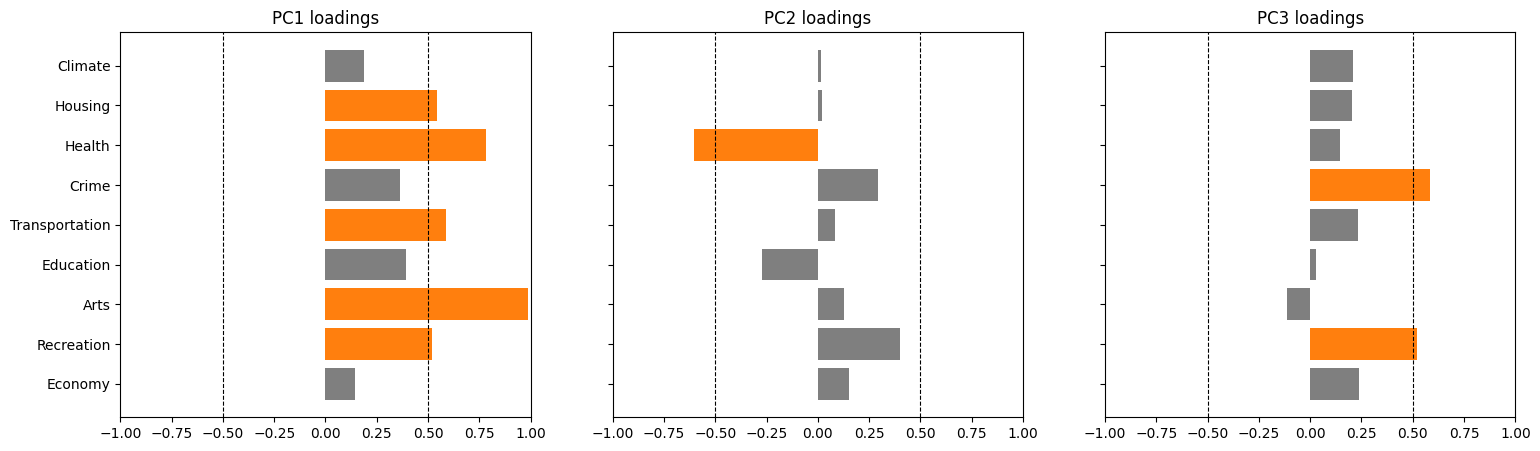

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, pc in zip(axes, loadings.columns):
    vals = loadings[pc]
    ax.barh(vals.index, vals, color=['tab:orange' if abs(v) > threshold else 'tab:grey' for v in vals])
    ax.axvline(threshold, color='k', linestyle='--', linewidth=0.8)
    ax.axvline(-threshold, color='k', linestyle='--', linewidth=0.8)
    ax.set_title(f'{pc} loadings'); ax.set_xlim(-1, 1)
axes[0].invert_yaxis()
plt.show()

**Communality** = sum of squared loadings across the 3 components, i.e. how much of each variable's variance these components explain.

In [7]:
communality = (loadings ** 2).sum(axis=1).sort_values(ascending=False)
print(communality.round(3))

Variable
Arts              0.998
Health            0.998
Recreation        0.701
Crime             0.562
Transportation    0.404
Housing           0.338
Education         0.230
Economy           0.100
Climate           0.079
dtype: float64


In [8]:
pc1 = loadings['PC1'].sort_values(ascending=False)
print("Answer")
print("---------------------------")
print(f"PC1 explains the most variance ({variance['PC1']:.3f} vs {variance['PC2']:.3f} and {variance['PC3']:.3f}), so it is the principal component.")
print(f"The variable with the highest loading on PC1 is {pc1.index[0]} ({pc1.iloc[0]:.3f}), followed by {pc1.index[1]} ({pc1.iloc[1]:.3f}).")

Answer
---------------------------
PC1 explains the most variance (2.835 vs 0.735 and 0.842), so it is the principal component.
The variable with the highest loading on PC1 is Arts (0.985), followed by Health (0.782).


### Conclusion

- **PC1 is the principal component.** It explains far more variance than PC2 or PC3, and **Arts (0.985)** is the variable that dominates it, followed by Health (0.782), Transportation (0.585), Housing (0.544) and Recreation (0.520). All nine loadings on PC1 are positive, so PC1 measures the overall urban amenities and quality of life of a place, driven mainly by Arts and Health.
- **PC2** is defined mainly by **Health (−0.605)**, contrasted against Recreation (0.402). A high PC2 score means better recreation but poorer health care.
- **PC3** is defined by **Crime (0.585)** and **Recreation (0.519)**.
- **Arts** and **Health** have the highest communality (0.998 each, so they are almost fully explained by these 3 PCs), while **Climate** and **Economy** load weakly on all three.